In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Hello world")

Hello world


# What the dataset is about: 
It's an Shopify Sales-Orders dataset capturing transactional data — each row is one order with details about the customer, product, pricing, discounts, payment, shipping, and whether the item was returned. It's well-suited for sales performance, customer behavior, and profitability analysis.

In [2]:
data=pd.read_csv("shopify_sales_dataset_eda.csv")
data.head(10)

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
0,1,2023-04-13,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,0,86.03,86.03,64.95
1,2,2024-03-11,26825,5557,Sports,746.49,15,4,UAE,Email,PayPal,5.48,3.7,0,634.52,2538.08,2532.60
2,3,2025-05-10,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads,Apple Pay,11.27,3.2,0,609.01,3045.05,3033.78
3,4,2023-09-28,20691,7855,Footwear,512.39,0,3,UAE,Direct,Apple Pay,19.22,1.1,0,512.39,1537.17,1517.95
4,5,2023-04-17,24631,7789,Sports,415.89,25,3,UAE,Social Media,Debit Card,24.94,4.1,0,311.92,935.76,910.82
5,6,2023-03-13,29596,2796,Beauty,444.14,0,5,UAE,Social Media,Apple Pay,20.29,2.6,0,444.14,2220.70,2200.41
6,7,2024-12-01,11896,6012,Accessories,244.18,15,1,Canada,Social Media,Debit Card,23.91,1.4,0,207.55,207.55,183.64
7,8,2023-01-21,43857,4248,Beauty,457.16,25,1,USA,Email,Apple Pay,4.17,3.0,0,342.87,342.87,338.70
8,9,2024-09-06,10308,3966,Fashion,394.28,15,1,India,Direct,Cash on Delivery,18.09,4.9,0,335.14,335.14,317.05
9,10,2023-05-02,35168,7180,Electronics,363.69,30,2,UAE,Social Media,Apple Pay,23.80,2.4,1,254.58,509.16,485.36


In [3]:
data.columns

Index(['order_id', 'order_date', 'customer_id', 'product_id',
       'product_category', 'product_price', 'discount_percent', 'quantity',
       'customer_country', 'traffic_source', 'payment_method', 'shipping_cost',
       'rating', 'is_returned', 'discounted_price', 'revenue', 'profit'],
      dtype='object')

| Column             | Meaning                      |
| ------------------ | ---------------------------- |
| `order_id`         | Unique order number          |
| `order_date`       | Date of purchase             |
| `customer_id`      | Unique customer              |
| `product_id`       | Unique product               |
| `product_category` | Product type/category        |
| `product_price`    | Original product price       |
| `discount_percent` | Discount offered             |
| `quantity`         | Units purchased              |
| `customer_country` | Customer location            |
| `traffic_source`   | How customer came to website |
| `payment_method`   | Payment used                 |
| `shipping_cost`    | Delivery charges             |
| `rating`           | Customer rating              |
| `is_returned`      | Returned or not (0/1)        |
| `discounted_price` | Final selling price          |
| `revenue`          | Total revenue generated      |
| `profit`           | Profit earned                |


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          60000 non-null  int64  
 1   order_date        60000 non-null  object 
 2   customer_id       60000 non-null  int64  
 3   product_id        60000 non-null  int64  
 4   product_category  60000 non-null  object 
 5   product_price     60000 non-null  float64
 6   discount_percent  60000 non-null  int64  
 7   quantity          60000 non-null  int64  
 8   customer_country  60000 non-null  object 
 9   traffic_source    60000 non-null  object 
 10  payment_method    60000 non-null  object 
 11  shipping_cost     60000 non-null  float64
 12  rating            60000 non-null  float64
 13  is_returned       60000 non-null  int64  
 14  discounted_price  60000 non-null  float64
 15  revenue           60000 non-null  float64
 16  profit            60000 non-null  float6

# data contain orderDate as object

In [5]:
data.describe().round(2)

,order_id,customer_id,product_id,product_price,discount_percent,quantity,shipping_cost,rating,is_returned,discounted_price,revenue,profit
count,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00
mean,30000.50,30035.08,4504.74,403.43,18.15,3.01,13.52,3.00,0.15,330.22,994.10,980.58
std,17320.65,11540.75,2018.29,230.05,12.53,1.41,6.63,1.15,0.36,197.11,806.45,806.51
min,1.00,10000.00,1000.00,5.01,0.00,1.00,2.00,1.00,0.00,3.08,3.08,-20.49
25%,15000.75,20037.75,2751.75,203.16,5.00,2.00,7.76,2.00,0.00,161.96,355.62,341.92
50%,30000.50,30079.00,4503.50,403.86,20.00,3.00,13.58,3.00,0.00,322.56,760.47,747.28
75%,45000.25,40036.25,6257.00,603.14,30.00,4.00,19.23,4.00,0.00,482.24,1462.45,1449.81
max,60000.00,49999.00,7999.00,799.99,40.00,5.00,25.00,5.00,1.00,799.90,3999.50,3989.95


In [6]:
data.describe(include="object")

,order_date,product_category,customer_country,traffic_source,payment_method
count,60000,60000,60000,60000,60000
unique,900,7,7,5,5
top,2024-10-18,Electronics,Australia,Organic,Apple Pay
freq,92,8624,8714,12075,12116


In [7]:
data.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_id          0
product_category    0
product_price       0
discount_percent    0
quantity            0
customer_country    0
traffic_source      0
payment_method      0
shipping_cost       0
rating              0
is_returned         0
discounted_price    0
revenue             0
profit              0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data['order_date']=pd.to_datetime(data['order_date'],dayfirst=True)
data['order_date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 60000 entries, 0 to 59999
Series name: order_date
Non-Null Count  Dtype         
--------------  -----         
60000 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 468.9 KB


C:\Users\Administrator\AppData\Local\Temp\ipykernel_26336\1589602493.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  data['order_date']=pd.to_datetime(data['order_date'],dayfirst=True)


In [10]:
data['month'] = data['order_date'].dt.month
data['month_name']=data['order_date'].dt.month_name()
data['year'] = data['order_date'].dt.year
data['quarter']=data['order_date'].dt.quarter
data[['month','year','quarter']]

,month,year,quarter
0,4,2023,2
1,3,2024,1
2,5,2025,2
3,9,2023,3
4,4,2023,2
...,...,...,...
59995,4,2025,2
59996,9,2024,3
59997,11,2024,4
59998,9,2023,3


In [11]:
data.columns

Index(['order_id', 'order_date', 'customer_id', 'product_id',
       'product_category', 'product_price', 'discount_percent', 'quantity',
       'customer_country', 'traffic_source', 'payment_method', 'shipping_cost',
       'rating', 'is_returned', 'discounted_price', 'revenue', 'profit',
       'month', 'month_name', 'year', 'quarter'],
      dtype='object')

In [12]:
print("1. DATASET OVERVIEW")
print(f"Shape           : {data.shape}")
print(f"Date range      : {data['order_date'].min().date()} → {data['order_date'].max().date()}")
print(f"Missing values  : {data.isnull().sum().sum()}")
print(f"Duplicate rows  : {data.duplicated().sum()}")
print("="*120)
print("Total orders:",data['order_id'].count())
print("Total revenue:",data['revenue'].sum())
print("Avg revenue:",data['revenue'].mean().round(2))
print("Total Number of Returned Orders:",data['is_returned'].sum())
print("Return Rate %:",(data['is_returned'].sum()/data['order_id'].count()*100).round(2))
print("Avg Rating",data['rating'].mean().round(2),"/5")
print("Total Profit:",data['profit'].sum())
print("="*120)
print("Number of countries:",data['customer_country'].nunique())
print("Unique countries:",data['customer_country'].unique())
print("Number of products Categories:",data['product_category'].nunique())
print("Unique products:",data['product_category'].unique())
print("Number of Traffic Source:",data["traffic_source"].nunique())
print("Unique Traffic Source:",data["traffic_source"].unique())
print("Number of Payment Method:",data["payment_method"].nunique())
print("Unique Payment Method:",data["payment_method"].unique())


1. DATASET OVERVIEW
Shape           : (60000, 21)
Date range      : 2023-01-01 → 2025-06-18
Missing values  : 0
Duplicate rows  : 0
Total orders: 60000
Total revenue: 59645935.58
Avg revenue: 994.1
Total Number of Returned Orders: 8887
Return Rate %: 14.81
Avg Rating 3.0 /5
Total Profit: 58834630.1
Number of countries: 7
Unique countries: ['USA' 'UAE' 'Canada' 'India' 'UK' 'Germany' 'Australia']
Number of products Categories: 7
Unique products: ['Accessories' 'Sports' 'Electronics' 'Footwear' 'Beauty' 'Fashion'
 'Home Decor']
Number of Traffic Source: 5
Unique Traffic Source: ['Paid Ads' 'Email' 'Direct' 'Social Media' 'Organic']
Number of Payment Method: 5
Unique Payment Method: ['Credit Card' 'PayPal' 'Apple Pay' 'Debit Card' 'Cash on Delivery']


In [52]:
t=data.groupby("product_category").agg({"order_id":"count","discount_percent":'mean',"quantity":'sum',"shipping_cost":'sum',"rating":'mean',"is_returned":'sum'	,"revenue":'sum',"profit":"sum"})
t.rename(columns={"order_id":"No of Orders","discount_percent":"AVG Discount","quantity":'Total Quantity',"shipping_cost":'Total Shipping Cost',"rating":'AVG Rating',"is_returned":'No of Return orders',"revenue":'Total Revenue',"profit":"Total Profit"})


,No of Orders,AVG Discount,Total Quantity,Total Shipping Cost,AVG Rating,No of Return orders,Total Revenue,Total Profit
product_category,,,,,,,,
Accessories,8617,18.361379,26060,116232.62,2.990890,1262,8609171.52,8492938.90
Beauty,8586,17.991498,25757,115805.35,3.003657,1289,8544881.95,8429076.60
Electronics,8624,17.865840,26075,116233.48,3.015283,1262,8717301.49,8601068.01
Fashion,8594,18.026530,25925,117228.52,2.983779,1292,8445072.67,8327844.15
Footwear,8457,18.322100,25350,113860.14,3.010689,1245,8348968.69,8235108.55
Home Decor,8600,18.166279,25907,117176.31,3.006116,1240,8545840.45,8428664.14
Sports,8522,18.331378,25500,114769.06,3.006818,1297,8434698.81,8319929.75


In [53]:
t=data.groupby("customer_country").agg({"order_id":"count","discount_percent":'mean',"quantity":'sum',"shipping_cost":'sum',"rating":'mean',"is_returned":'sum'	,"revenue":'sum',"profit":"sum"})
t.rename(columns={"order_id":"No of Orders","discount_percent":"AVG Discount","quantity":'Total Quantity',"shipping_cost":'Total Shipping Cost',"rating":'AVG Rating',"is_returned":'No of Return orders',"revenue":'Total Revenue',"profit":"Total Profit"})

,No of Orders,AVG Discount,Total Quantity,Total Shipping Cost,AVG Rating,No of Return orders,Total Revenue,Total Profit
customer_country,,,,,,,,
Australia,8714,18.327404,26258,118071.85,2.986734,1292,8698940.71,8580868.86
Canada,8586,18.078849,25652,115716.94,2.997321,1313,8506629.46,8390912.52
Germany,8606,18.346502,25986,116624.91,3.007297,1328,8566995.25,8450370.34
India,8554,17.934300,25774,115773.09,3.037421,1251,8509138.00,8393364.91
UAE,8599,18.144552,25889,116521.05,2.996255,1276,8541233.92,8424712.87
UK,8472,18.171034,25394,114434.03,2.992670,1213,8372019.42,8257585.39
USA,8469,18.052899,25621,114163.61,2.999575,1214,8450978.82,8336815.21


In [54]:
t=data.groupby("traffic_source").agg({"order_id":"count","discount_percent":'mean',"quantity":'sum',"shipping_cost":'sum',"rating":'mean',"is_returned":'sum'	,"revenue":'sum',"profit":"sum"})
t.rename(columns={"order_id":"No of Orders","discount_percent":"AVG Discount","quantity":'Total Quantity',"shipping_cost":'Total Shipping Cost',"rating":'AVG Rating',"is_returned":'No of Return orders',"revenue":'Total Revenue',"profit":"Total Profit"})

,No of Orders,AVG Discount,Total Quantity,Total Shipping Cost,AVG Rating,No of Return orders,Total Revenue,Total Profit
traffic_source,,,,,,,,
Direct,11961,18.243876,36151,161572.99,3.002241,1715,11953141.33,11791568.34
Email,11922,18.160544,35919,161625.58,3.003213,1740,11823943.67,11662318.09
Organic,12075,18.192961,36025,163674.26,3.004729,1881,11907664.90,11743990.64
Paid Ads,12018,18.138209,36077,163149.58,2.996355,1760,11939378.20,11776228.62
Social Media,12024,18.022289,36402,161283.07,3.005655,1791,12021807.48,11860524.41


In [55]:
t=data.groupby("payment_method").agg({"order_id":"count","discount_percent":'mean',"quantity":'sum',"shipping_cost":'sum',"rating":'mean',"is_returned":'sum'	,"revenue":'sum',"profit":"sum"})
t.rename(columns={"order_id":"No of Orders","discount_percent":"AVG Discount","quantity":'Total Quantity',"shipping_cost":'Total Shipping Cost',"rating":'AVG Rating',"is_returned":'No of Return orders',"revenue":'Total Revenue',"profit":"Total Profit"})

,No of Orders,AVG Discount,Total Quantity,Total Shipping Cost,AVG Rating,No of Return orders,Total Revenue,Total Profit
payment_method,,,,,,,,
Apple Pay,12116,18.226312,36640,163864.61,3.009401,1801,12109957.21,11946092.60
Cash on Delivery,12032,18.110040,36073,162031.13,2.990484,1755,11870651.24,11708620.11
Credit Card,11998,18.193449,36182,162578.30,3.001259,1730,11898249.20,11735670.90
Debit Card,11936,18.241454,36007,161409.15,3.000712,1751,11903139.90,11741730.75
PayPal,11918,17.984981,35672,161422.29,3.010354,1850,11863938.03,11702515.74


In [82]:
y=data.groupby('year')['revenue'].sum().reset_index()
print("Revenue Growth over YOY from 2023 to 2024 :"+str(((y[y['year']==2024].iloc[0]["revenue"]-y[y['year']==2023].iloc[0]["revenue"])/(y[y['year']==2023].iloc[0]["revenue"])*100).round(2))+"%")

Revenue Growth over YOY from 2023 to 2024 :0.46%


# Data Visualization

In [13]:
sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5),
                     'axes.titlesize': 14, 'axes.titleweight': 'bold'})

#  Sales Performance Analysis

# Yearly-Monthly & seasonal revenue trends
Which months or quarters drive the most revenue? Are there peak periods worth targeting?

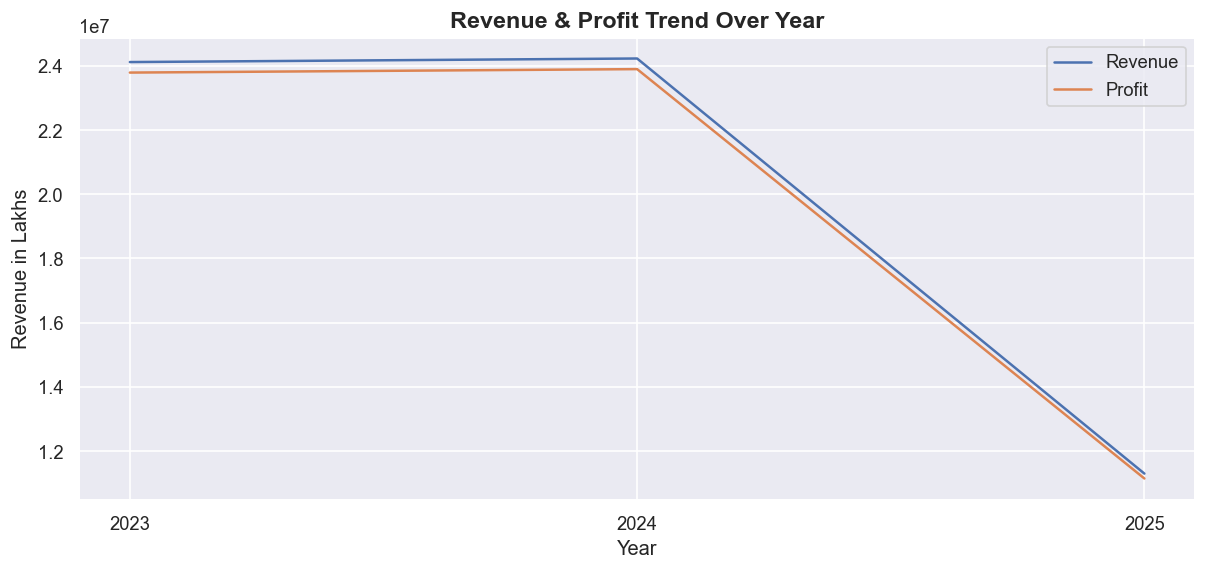

In [14]:
t = data.groupby("year")[['revenue', 'profit']].sum().reset_index()
t['year']=t['year'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(t['year'],t['revenue'],label="Revenue")
plt.plot(t['year'],t['profit'],label="Profit")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Revenue in Lakhs")
plt.title("Revenue & Profit Trend Over Year")
plt.show()

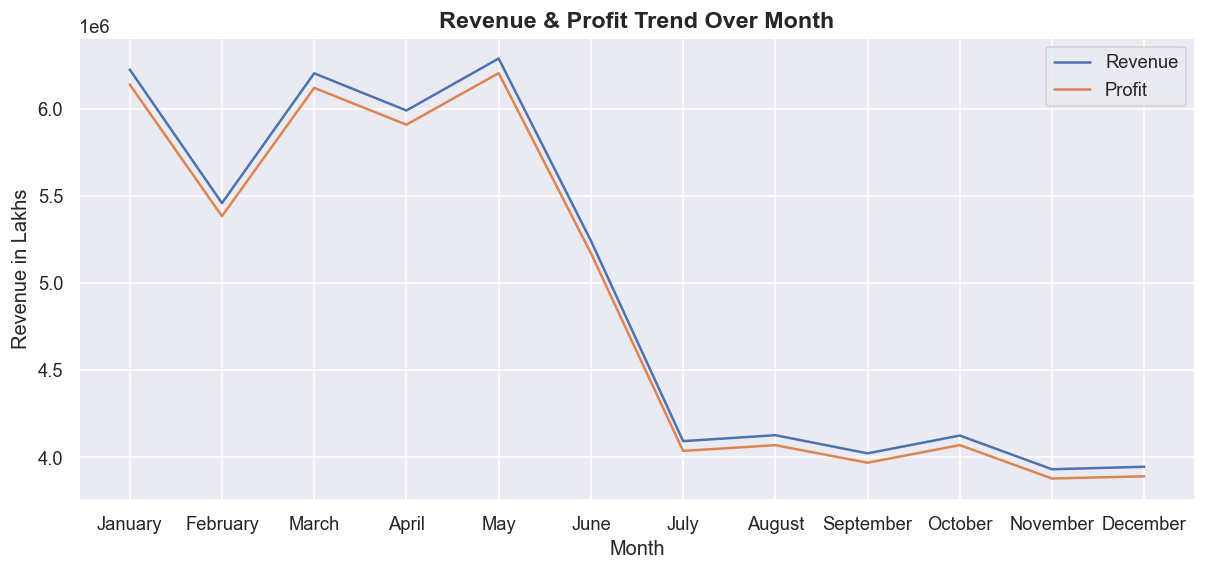

In [15]:
t = data.groupby(["month",'month_name'])[['revenue', 'profit']].sum().reset_index()
plt.figure(figsize=(12, 5))
plt.plot(t['month_name'],t['revenue'],label="Revenue")
plt.plot(t['month_name'],t['profit'],label="Profit")
plt.legend()
plt.xlabel("Month")
plt.ylabel("Revenue in Lakhs")
plt.title("Revenue & Profit Trend Over Month")
plt.show()

# Year-over-Year Monthly Order Comparison

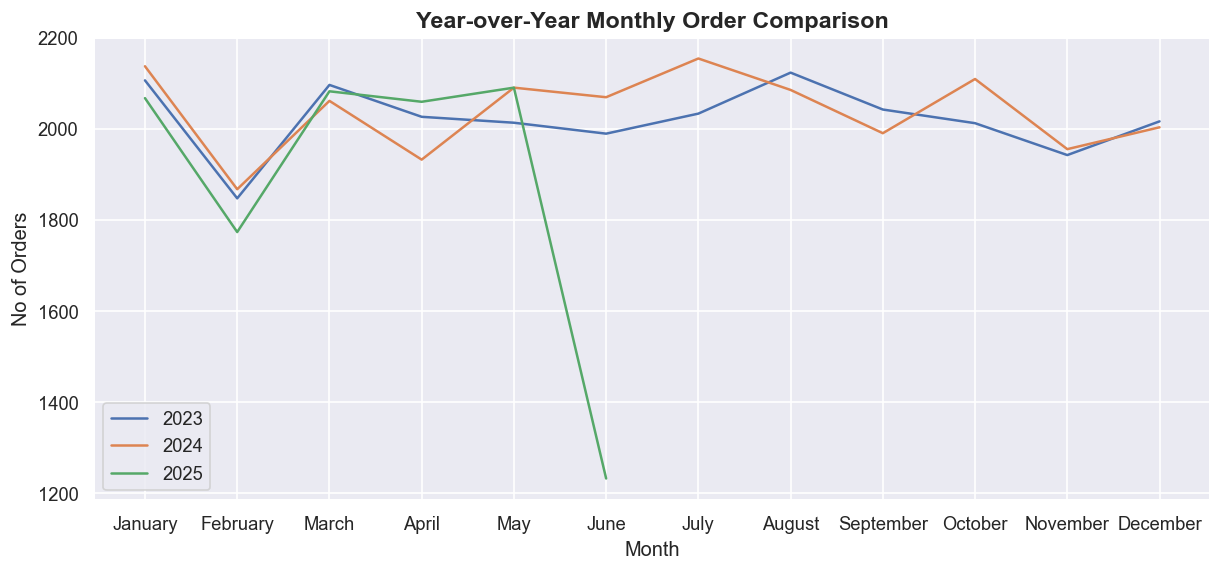

In [16]:
t2023=data[data['year']==2023].groupby(["month",'month_name']).agg({'order_id':'count'}).reset_index().sort_values(ascending=True,by="month")
t2024=data[data['year']==2024].groupby(["month",'month_name']).agg({'order_id':'count'}).reset_index().sort_values(ascending=True,by="month")
t2025=data[data['year']==2025].groupby(["month",'month_name']).agg({'order_id':'count'}).reset_index().sort_values(ascending=True,by="month")

plt.plot(t2023['month_name'],t2023['order_id'],label="2023")
plt.plot(t2024['month_name'],t2024['order_id'],label="2024")
plt.plot(t2025['month_name'],t2025['order_id'],label="2025")

plt.xlabel("Month")
plt.ylabel("No of Orders")
plt.title("Year-over-Year Monthly Order Comparison")
plt.legend()
plt.show()

# Analyze Product Category Sales Performance


Identify which product categories generate maximum sales revenue.

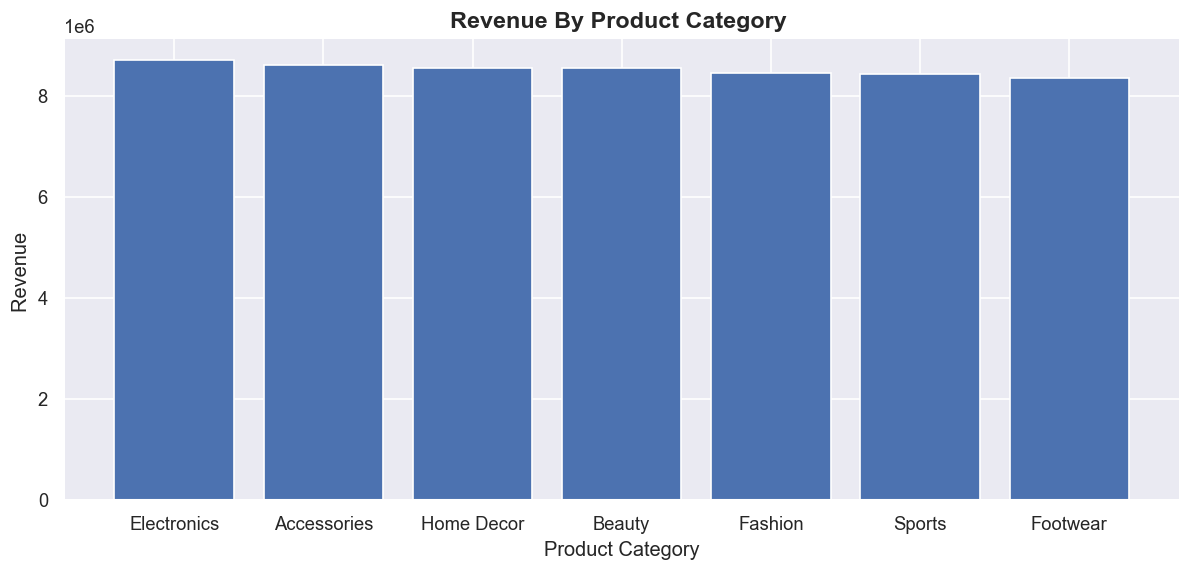

In [17]:
t = data.groupby('product_category').agg({'revenue':'sum', 'profit':'sum','order_id':'count'}).reset_index().sort_values(ascending=False, by="revenue")
plt.bar(t['product_category'],t['revenue'])
plt.xlabel("Product Category")
plt.ylabel("Revenue ")
plt.title("Revenue By Product Category ")
plt.show()

# Analyze Quantity Sold by Product Category


Analyze the number of products sold in each category.

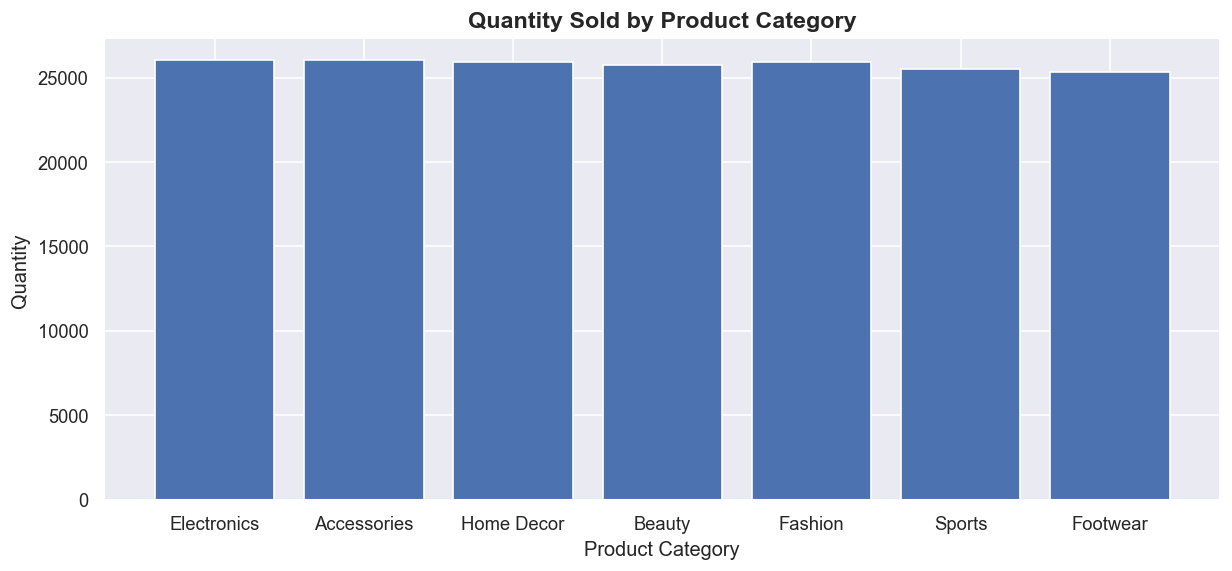

In [18]:
t = data.groupby('product_category').agg({'revenue':'sum', 'profit':'sum','quantity':'sum'}).reset_index().sort_values(ascending=False, by="revenue")
plt.bar(t['product_category'],t['quantity'])
plt.xlabel("Product Category")
plt.ylabel("Quantity ")
plt.title("Quantity Sold by Product Category")
plt.show()

# PROFITABILITY ANALYSIS

# Analyze Profit by Product Category

Identify the most profitable product categories.

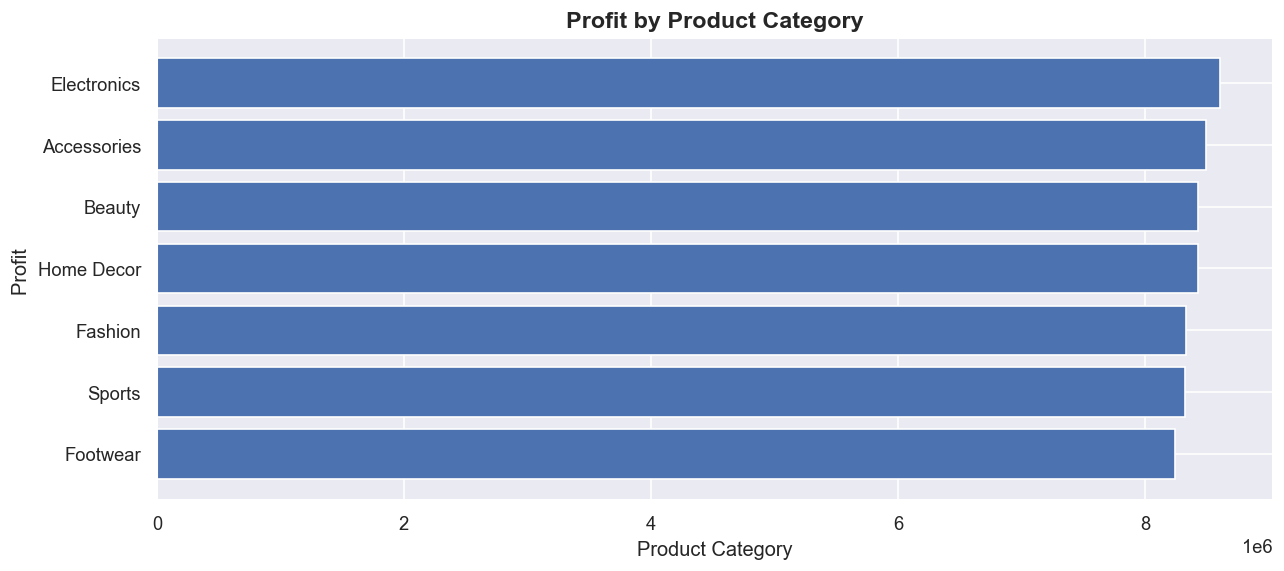

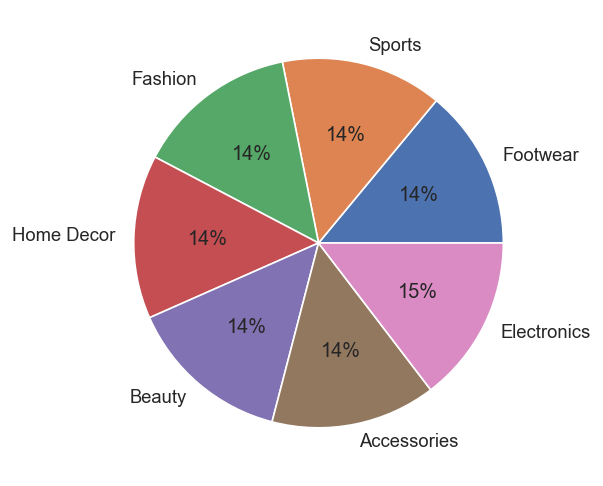

In [19]:
t = data.groupby('product_category').agg({'revenue':'sum', 'profit':'sum','quantity':'sum'}).reset_index().sort_values(ascending=True, by="profit")
plt.barh(t['product_category'],t['profit'])
plt.xlabel("Product Category")
plt.ylabel("Profit ")
plt.title("Profit by Product Category")
plt.show()


plt.pie(autopct="%0.0f%%",data=t,x=t["revenue"],labels=t['product_category'])
plt.show()

# Analyze Revenue vs Profit Relationship

Analyze the relationship between revenue and profit.

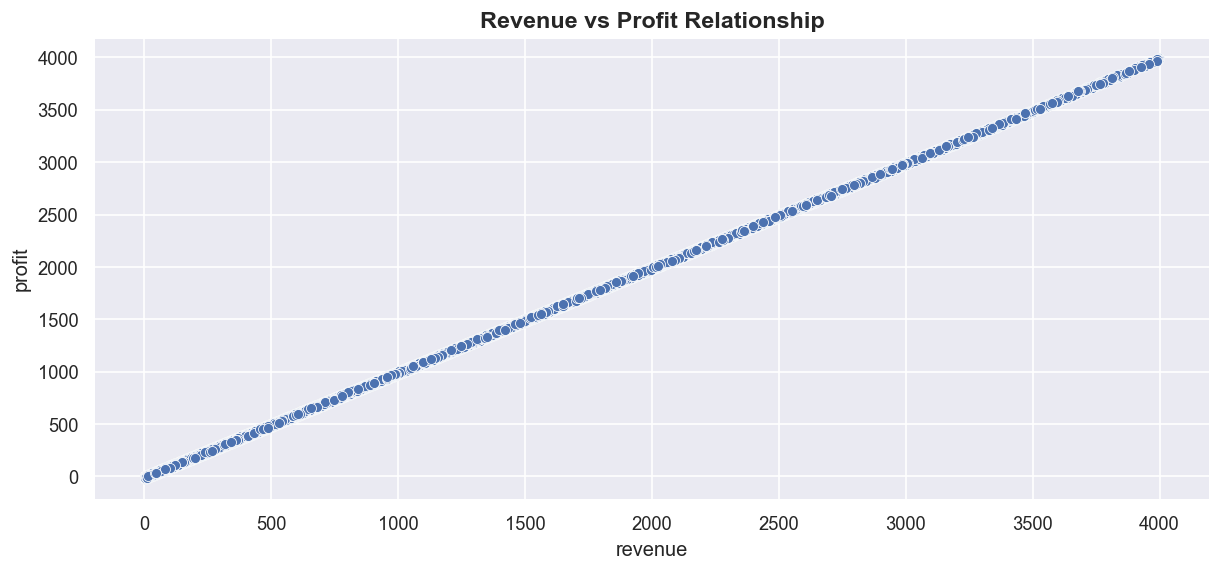

In [20]:
sns.scatterplot(x=data['revenue'],y=data['profit'])
plt.title("Revenue vs Profit Relationship")
plt.show()

### Both has linear growth

# Analyze Profit Margin by Category

Calculate and compare profit margins across product categories.

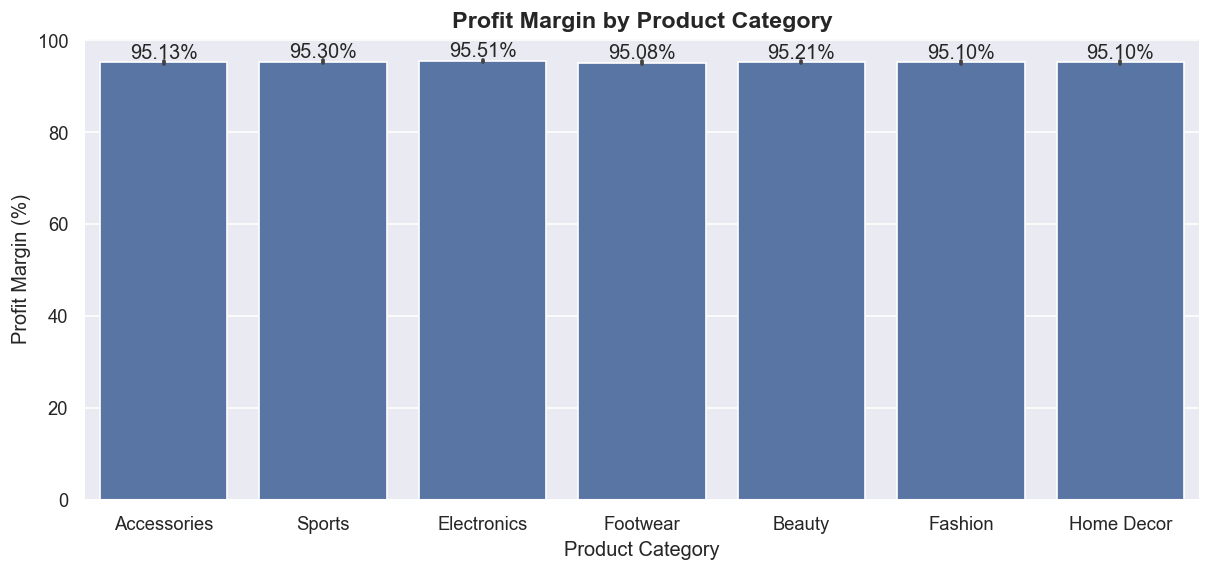

In [21]:
data['profit_margin']=data['profit']/data['revenue']*100
bar=sns.barplot(x=data['product_category'],y=data['profit_margin'])
bar.bar_label(bar.containers[0], fmt="{:,.2f}%")


plt.xlabel("Product Category")
plt.ylabel("Profit Margin (%)")
plt.title("Profit Margin by Product Category") 
plt.show()

# Top 5 Highest Profit Orders
Identify transactions generating the highest profit.

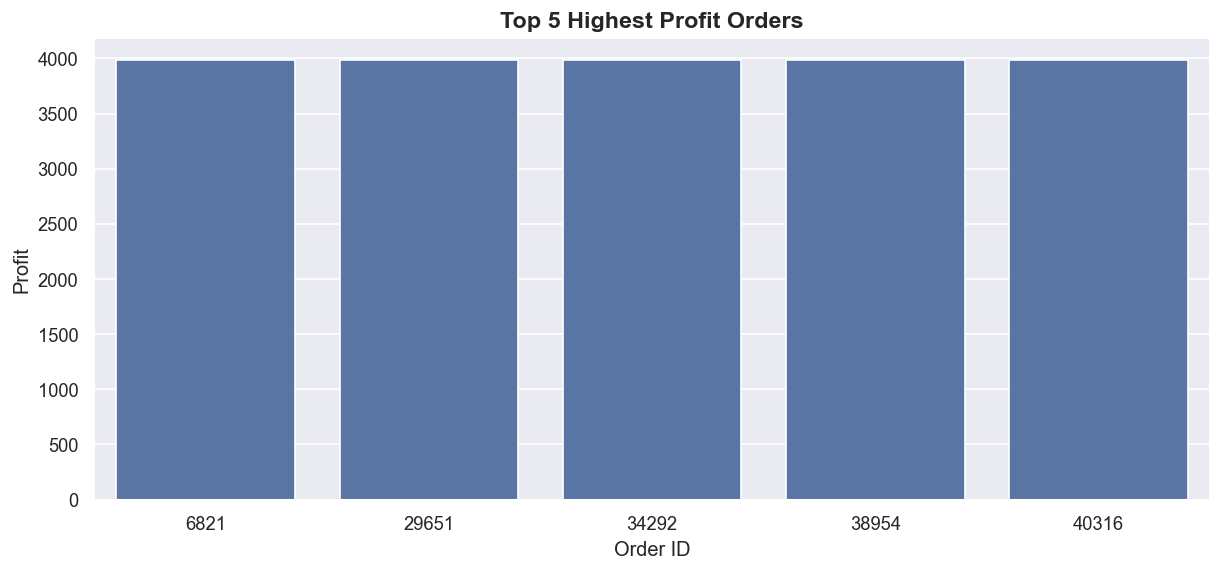

In [22]:
t = data.groupby('order_id').agg({'profit':'sum'}).reset_index().sort_values(ascending=False,by="profit").head(5)

sns.barplot(x=t['order_id'],y=t['profit'])



plt.xlabel("Order ID")
plt.ylabel("Profit")
plt.title("Top 5 Highest Profit Orders") 
plt.show()

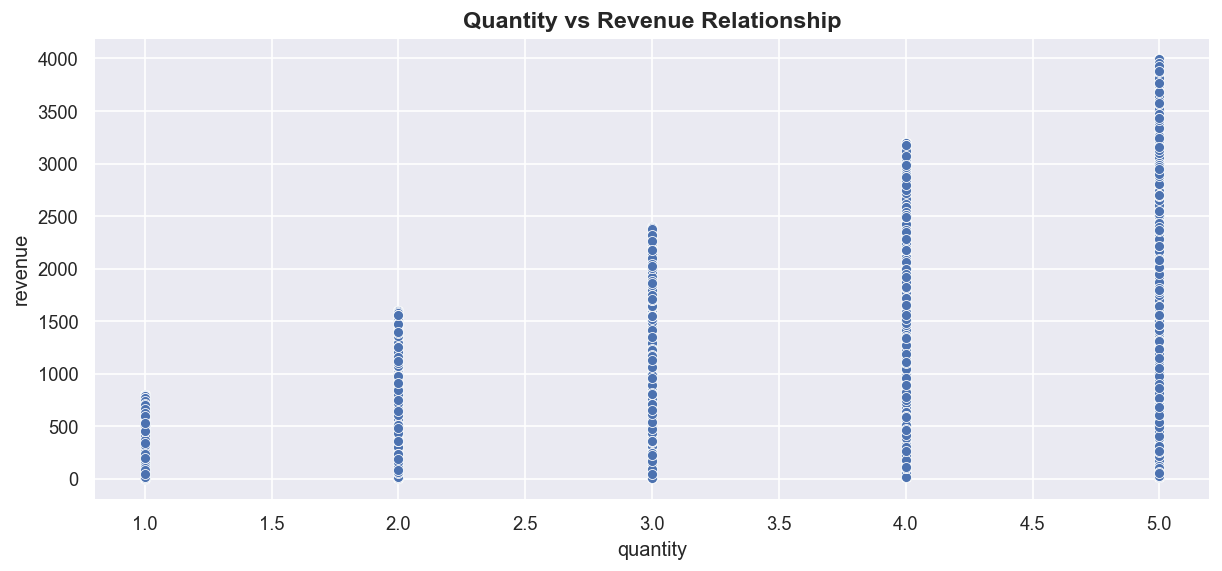

In [23]:
sns.scatterplot(x=data['quantity'],y=data['revenue'])
plt.title("Quantity vs Revenue Relationship")
plt.show()

# DISCOUNT IMPACT ANALYSIS

# Analyze Discount vs Revenue

Analyze how discounts affect revenue generation

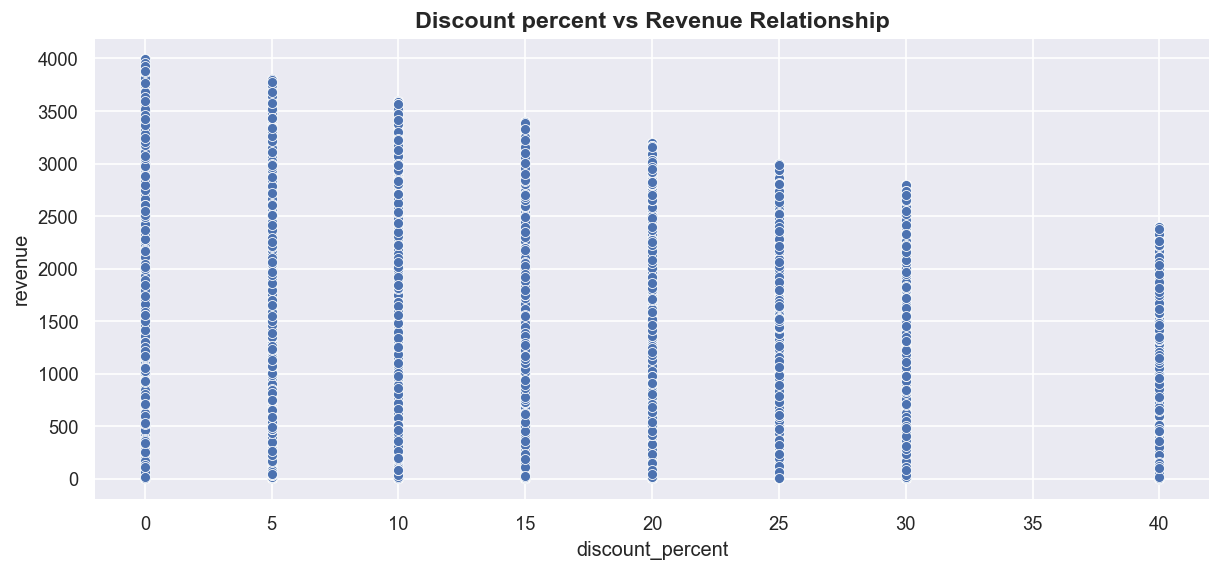

In [24]:
sns.scatterplot(x=data['discount_percent'],y=data['revenue'])
plt.title("Discount percent vs Revenue Relationship")
plt.show()

# Analyze Discount vs Profit

Study the impact of discounts on profitability.

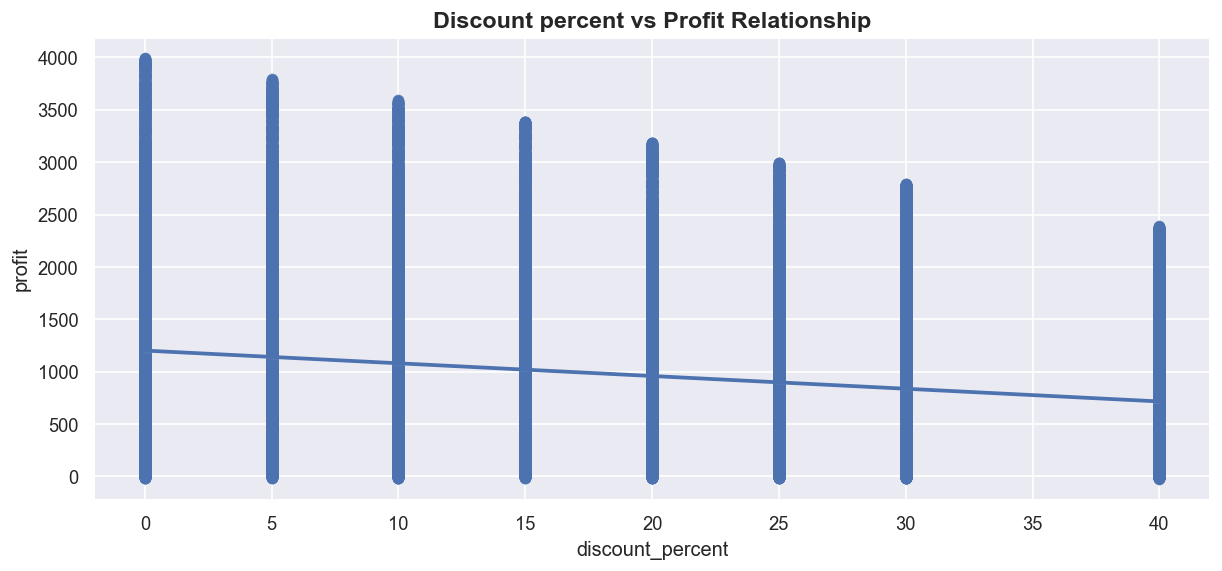

In [25]:
sns.regplot(x=data['discount_percent'],y=data['profit'])
plt.title("Discount percent vs Profit Relationship")
plt.show()

# Analyze Average Discount by Product Category

Compare average discounts offered across product categories.

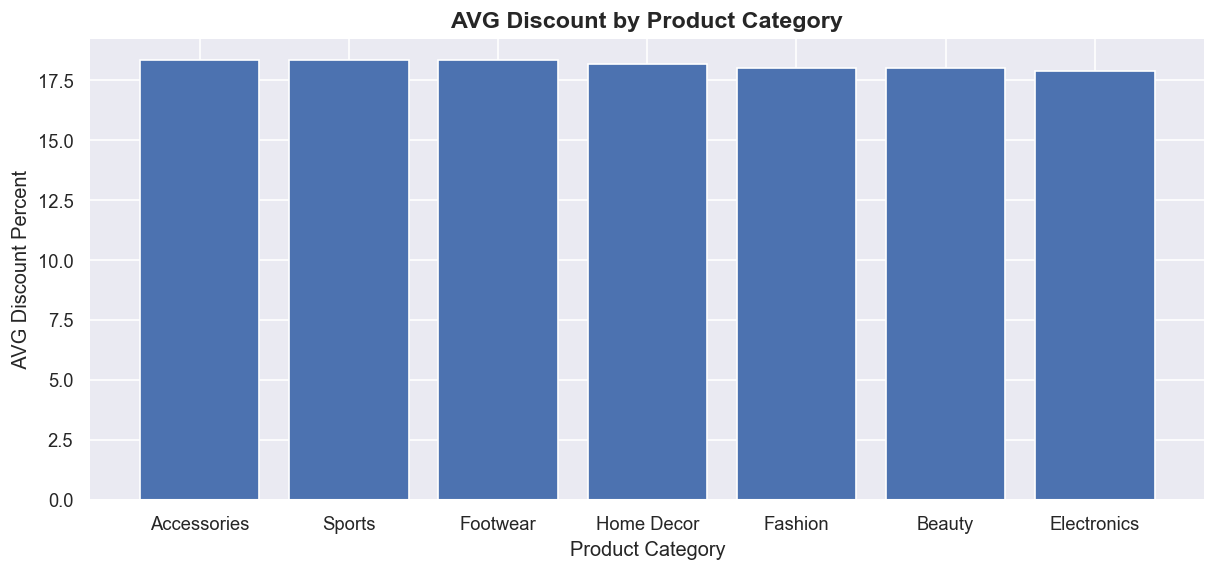

In [26]:
t = data.groupby('product_category').agg({'discount_percent':'mean'}).reset_index().sort_values(ascending=False,by='discount_percent')
plt.bar(t['product_category'],t['discount_percent'])
plt.xlabel("Product Category")
plt.ylabel(" AVG Discount Percent ")
plt.title("AVG Discount by Product Category")
plt.show()

# RETURN ANALYSIS

# Analyze Overall Product Return Distribution

Analyze how many products are returned versus not returned.

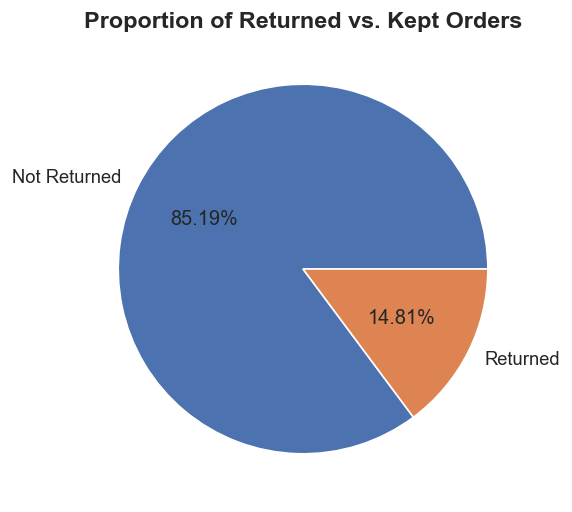

In [27]:
t=data.groupby('is_returned')['order_id'].count().reset_index()
t['is_returned']=t['is_returned'].map({0:'Not Returned',1:"Returned"})

plt.pie(t['order_id'], labels=t['is_returned'], autopct='%0.2f%%')

plt.title("Proportion of Returned vs. Kept Orders")
plt.show()

# Analyze Returns by Product Category

Identify product categories with the highest return rates.

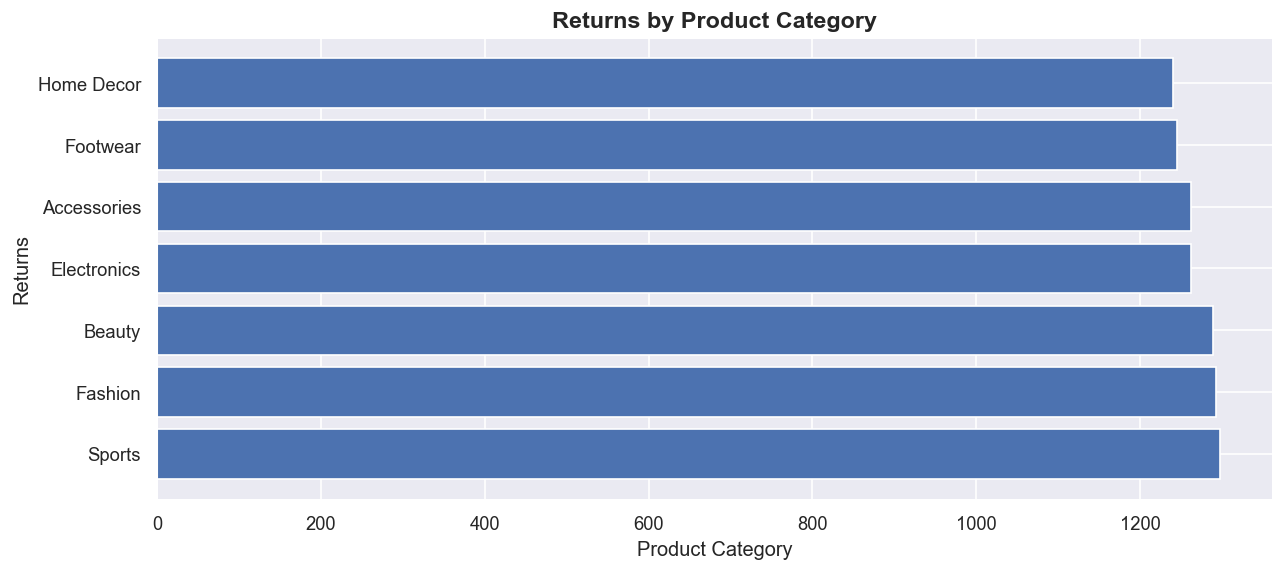

In [28]:
t = data.groupby('product_category').agg({'is_returned':'sum'}).reset_index().sort_values(ascending=False,by='is_returned')
plt.barh(t['product_category'],t['is_returned'])
plt.xlabel("Product Category")
plt.ylabel("Returns")
plt.title("Returns by Product Category")
plt.show()



# Analyze Returns by Country

Study return behavior across different countries.

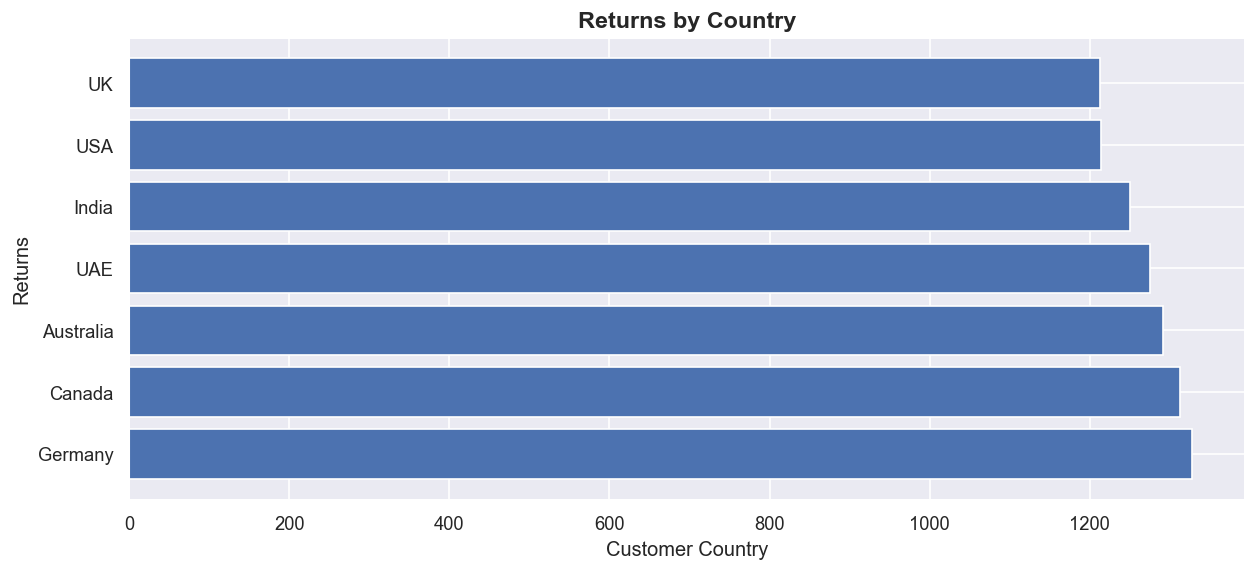

In [29]:
t = data.groupby('customer_country').agg({'is_returned':'sum'}).reset_index().sort_values(ascending=False,by='is_returned')
plt.barh(t['customer_country'],t['is_returned'])
plt.xlabel("Customer Country")
plt.ylabel("Returns")
plt.title("Returns by Country")
plt.show()

# MARKETING CHANNEL ANALYSIS

# Analyze Revenue by Traffic Source
Determine which traffic source generates the highest revenue.

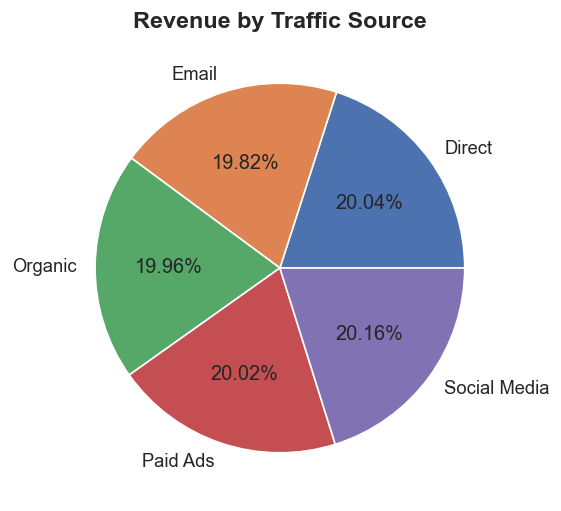

In [30]:
t=data.groupby('traffic_source')['revenue'].sum().reset_index()

plt.pie(t['revenue'], labels=t['traffic_source'], autopct='%0.2f%%')

plt.title("Revenue by Traffic Source")
plt.show()

# Analyze Profit by Traffic Source

Identify the most profitable marketing channel

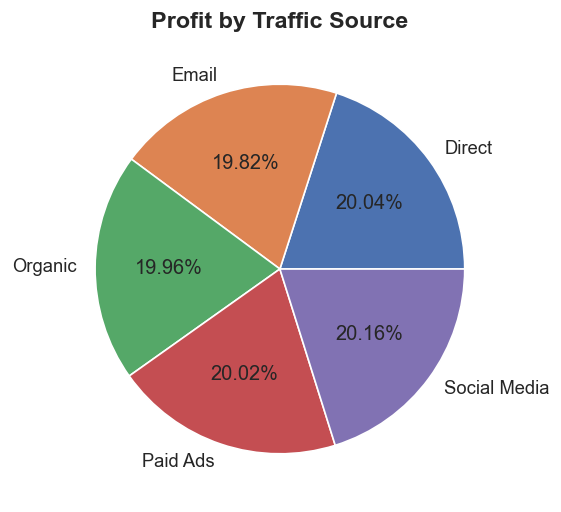

In [31]:
t=data.groupby('traffic_source')['profit'].sum().reset_index()

plt.pie(t['profit'], labels=t['traffic_source'], autopct='%0.2f%%')

plt.title("Profit by Traffic Source")
plt.show()

# Payment method distribution


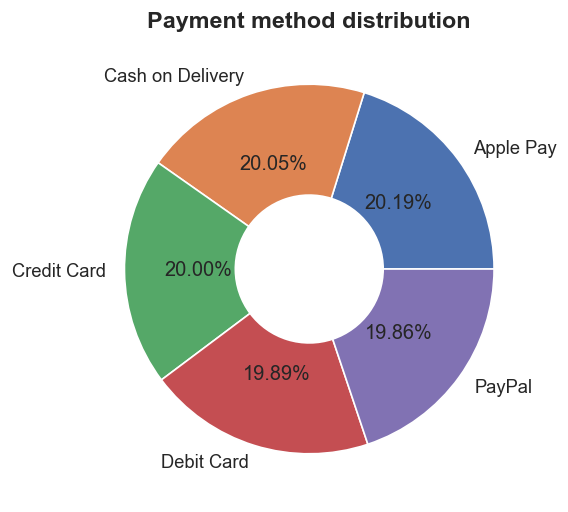

In [32]:
t=data.groupby('payment_method')['order_id'].count().reset_index()

plt.pie(t['order_id'], labels=t['payment_method'], autopct='%0.2f%%',wedgeprops={'width': 0.6, 'edgecolor': 'white'})

plt.title("Payment method distribution")
plt.show()

# COUNTRY-WISE SALES ANALYSIS

# Analyze Revenue by Country

Identify countries generating maximum revenue.

Which countries (USA, UAE, India, Canada) generate the most orders and revenue?

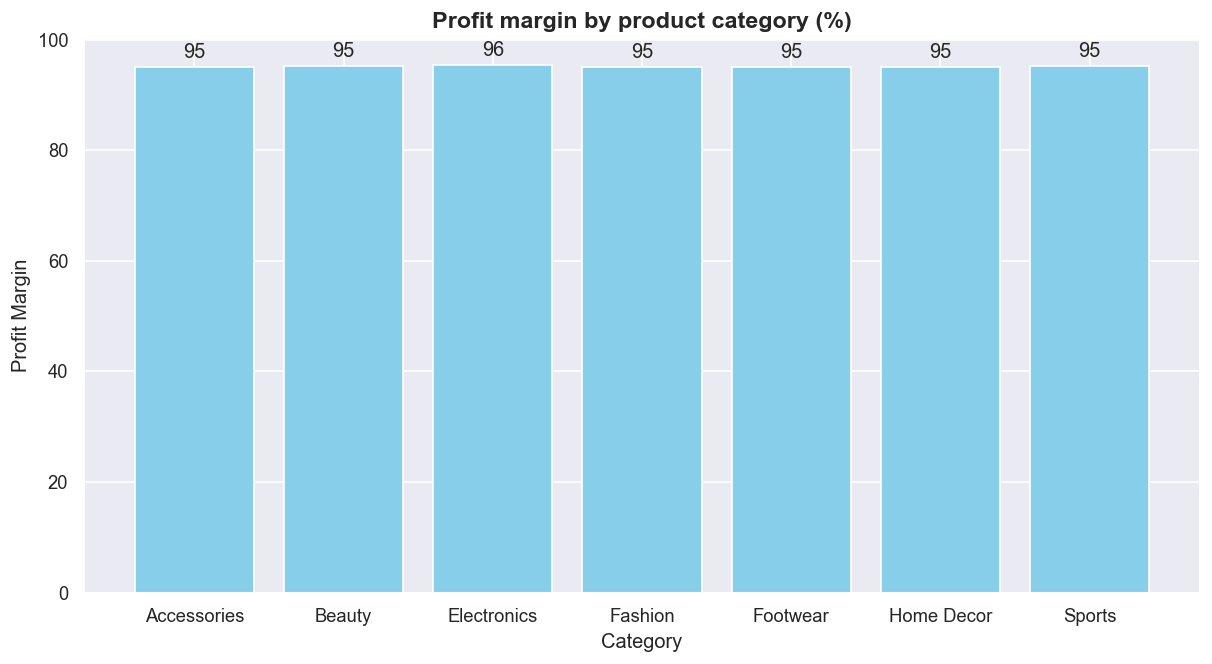

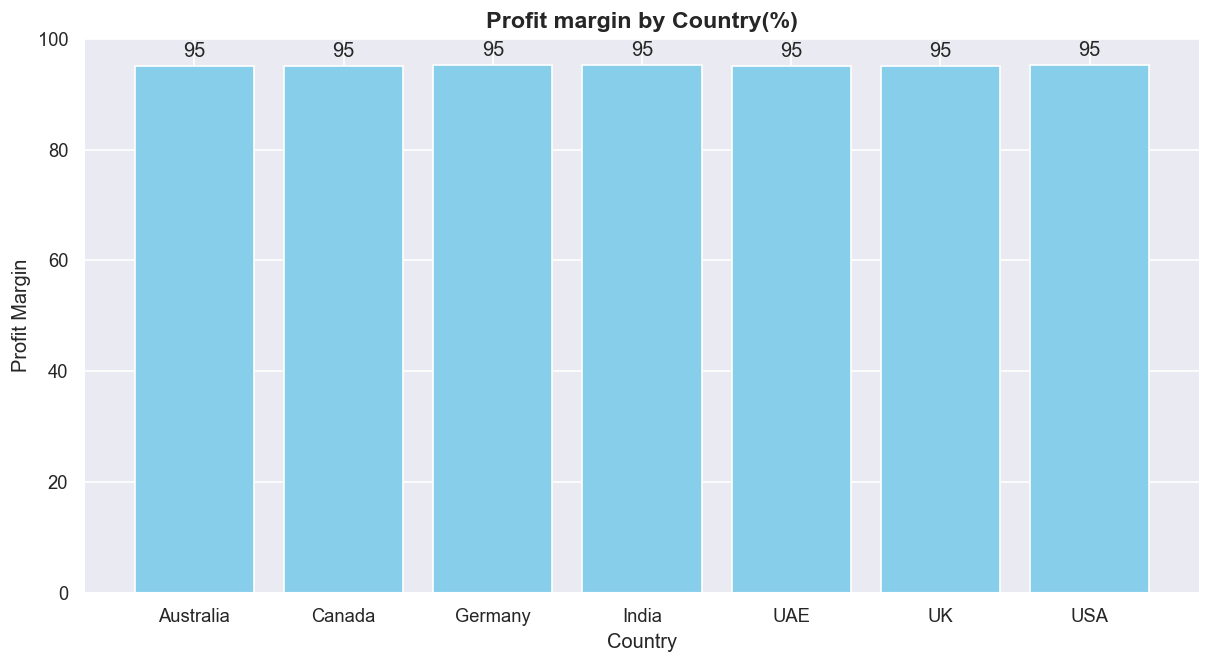

In [33]:
t = data.groupby('product_category')['profit_margin'].mean().reset_index()

plt.figure(figsize=(12, 6))
bars=plt.bar(t['product_category'],t['profit_margin'],color='skyblue')
plt.bar_label(bars, fmt='{:,.0f}', padding=3)

plt.xlabel("Category")
plt.ylabel("Profit Margin")
plt.title("Profit margin by product category (%)")

plt.show()

print("="*120)


t = data.groupby('customer_country')['profit_margin'].mean().reset_index()

plt.figure(figsize=(12, 6))
bars=plt.bar(t['customer_country'],t['profit_margin'],color='skyblue')
plt.bar_label(bars, fmt='{:,.0f}', padding=3)

plt.xlabel("Country")
plt.ylabel("Profit Margin")
plt.title("Profit margin by Country(%)")

plt.show()


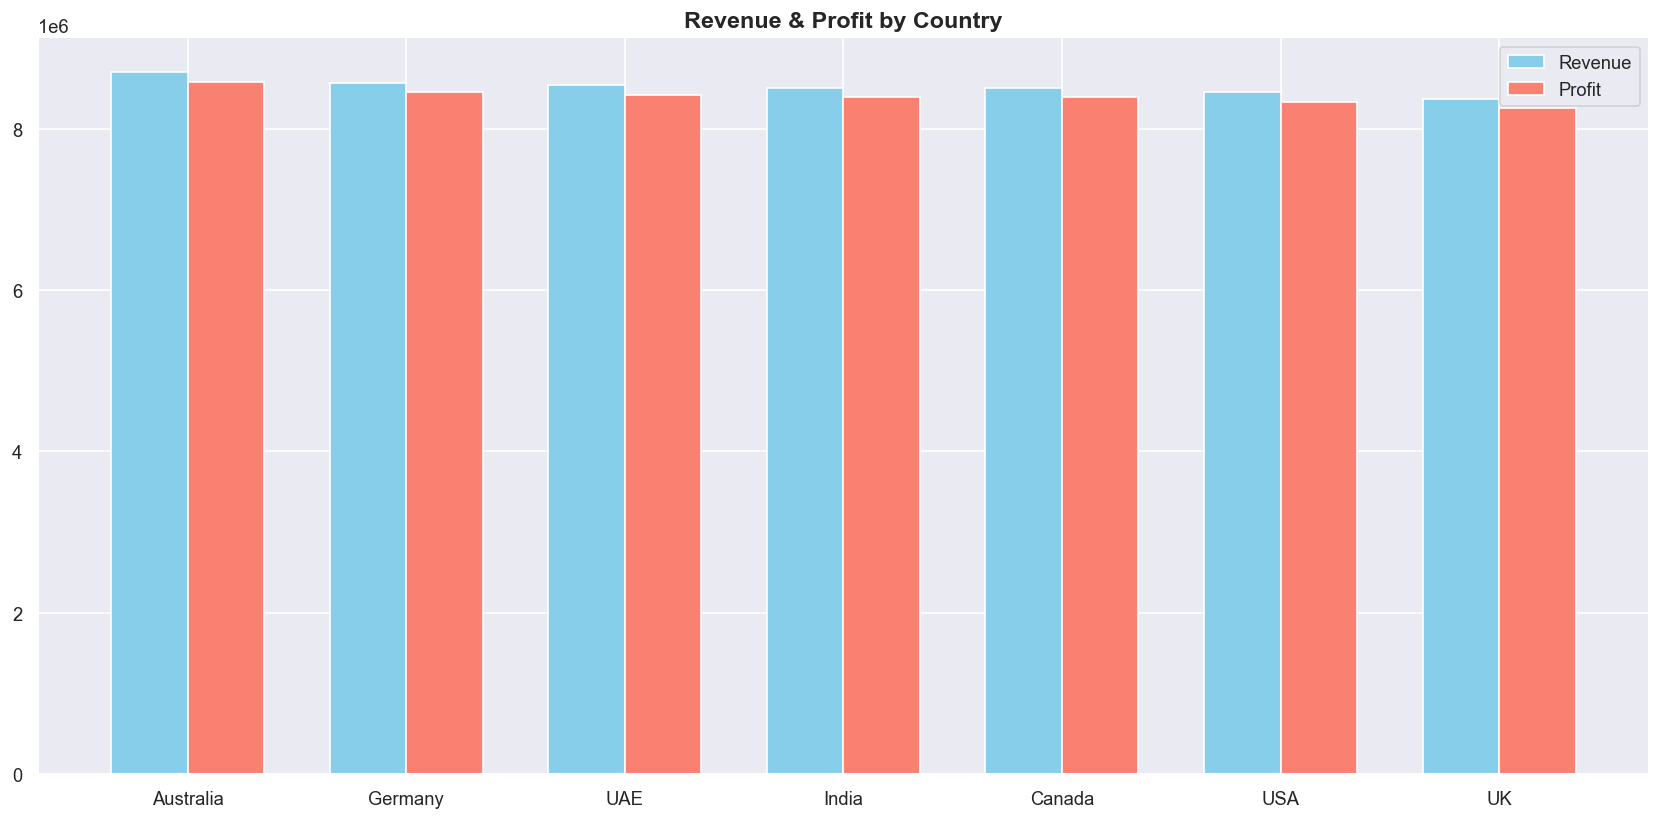

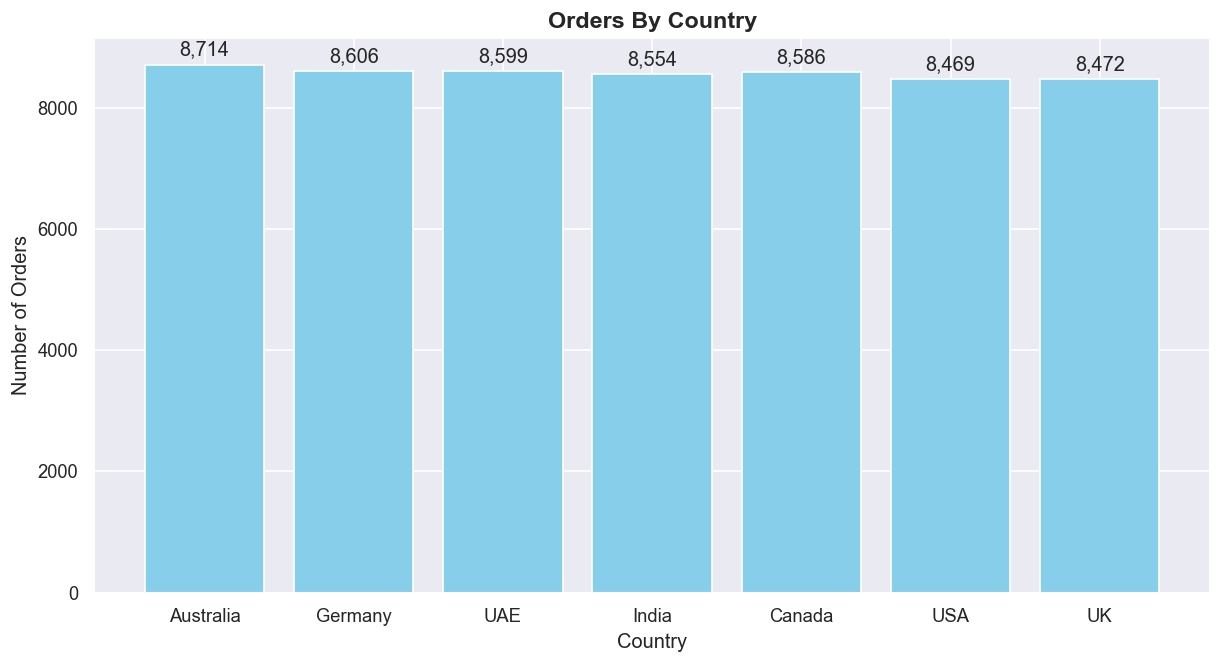

In [34]:

t = data.groupby('customer_country').agg({'revenue':'sum', 'profit':'sum','order_id':'count'}).reset_index().sort_values(ascending=False, by="revenue")

# 2. Plot a grouped bar chart
import numpy as np
x = np.arange(len(t['customer_country']))
width = 0.35

plt.figure(figsize=(14, 7))
bars1 = plt.bar(x - width/2, t['revenue'], width, label='Revenue', color='skyblue')
bars2 = plt.bar(x + width/2, t['profit'], width, label='Profit', color='salmon')
plt.title("Revenue & Profit by Country")
# 3. Add labels and formatting
plt.xticks(x, t['customer_country'])
plt.legend()
plt.tight_layout()
plt.show()

print('='*120)
# number of orders by country
plt.figure(figsize=(12, 6))
bars=plt.bar(t['customer_country'],t['order_id'],color='skyblue')
plt.bar_label(bars, fmt='{:,.0f}', padding=3)

plt.xlabel("Country")
plt.ylabel("Number of Orders")
plt.title("Orders By Country")
plt.show()

In [35]:
t = data.groupby('customer_country').agg({'revenue':'sum', 'profit':'sum','order_id':'count','rating':'mean'}).reset_index().sort_values(ascending=False, by="revenue")
t

,customer_country,revenue,profit,order_id,rating
0,Australia,8698940.71,8580868.86,8714,2.986734
2,Germany,8566995.25,8450370.34,8606,3.007297
4,UAE,8541233.92,8424712.87,8599,2.996255
3,India,8509138.00,8393364.91,8554,3.037421
1,Canada,8506629.46,8390912.52,8586,2.997321
6,USA,8450978.82,8336815.21,8469,2.999575
5,UK,8372019.42,8257585.39,8472,2.992670


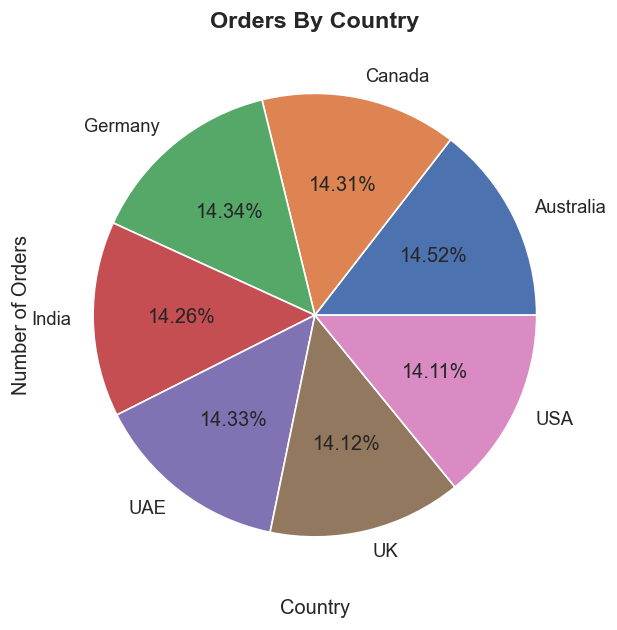

In [36]:
plt.figure(figsize=(12, 6))
t=data.groupby('customer_country')['order_id'].count().reset_index()

plt.pie(t['order_id'], labels=t['customer_country'], autopct='%0.2f%%')

plt.title("Profit by Traffic Source")


plt.xlabel("Country")
plt.ylabel("Number of Orders")
plt.title("Orders By Country")
plt.show()

# Analyze Average Ratings by Country

Compare customer satisfaction across countries.

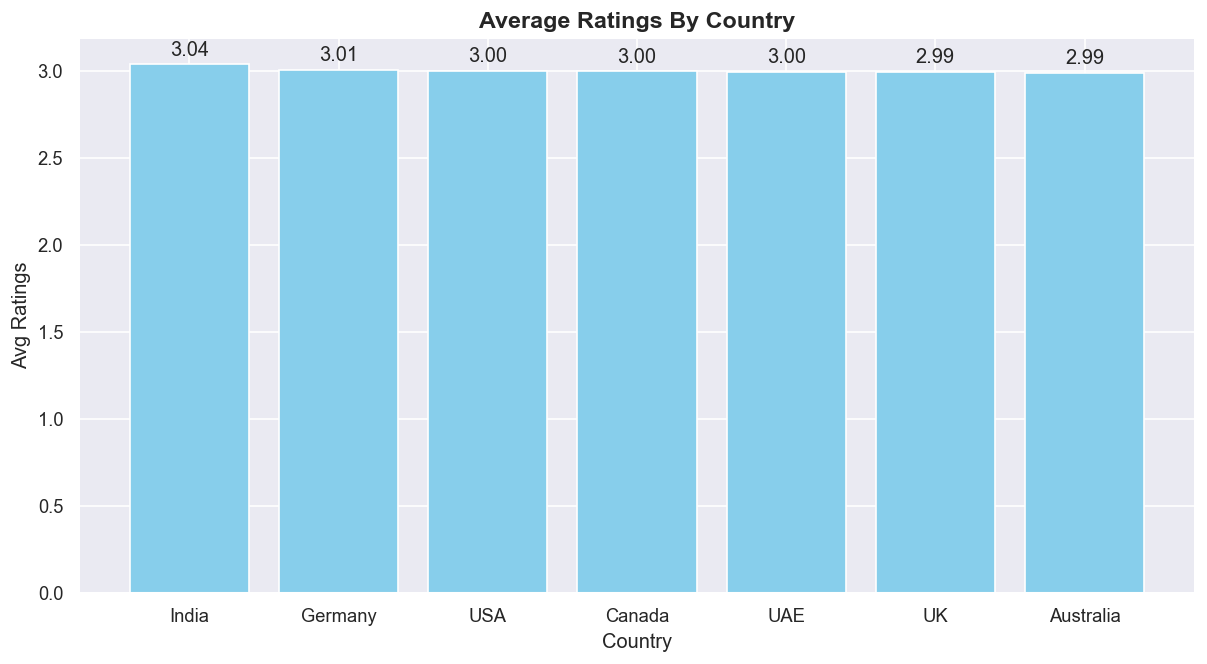

In [37]:
plt.figure(figsize=(12, 6))
t = data.groupby('customer_country').agg({'rating':'mean'}).reset_index().sort_values(ascending=False, by="rating")

bars=plt.bar(t['customer_country'],t['rating'],color='skyblue')
plt.bar_label(bars, fmt='{:,.2f}', padding=3)

plt.xlabel("Country")
plt.ylabel("Avg Ratings")
plt.title("Average Ratings By Country")
plt.show()

# Detect Outliers in Revenue and Profit


Identify unusual revenue and profit values affecting analysis.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26336\1111220247.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data['profit'], data['revenue']], labels=['Profit', 'Revenue'])


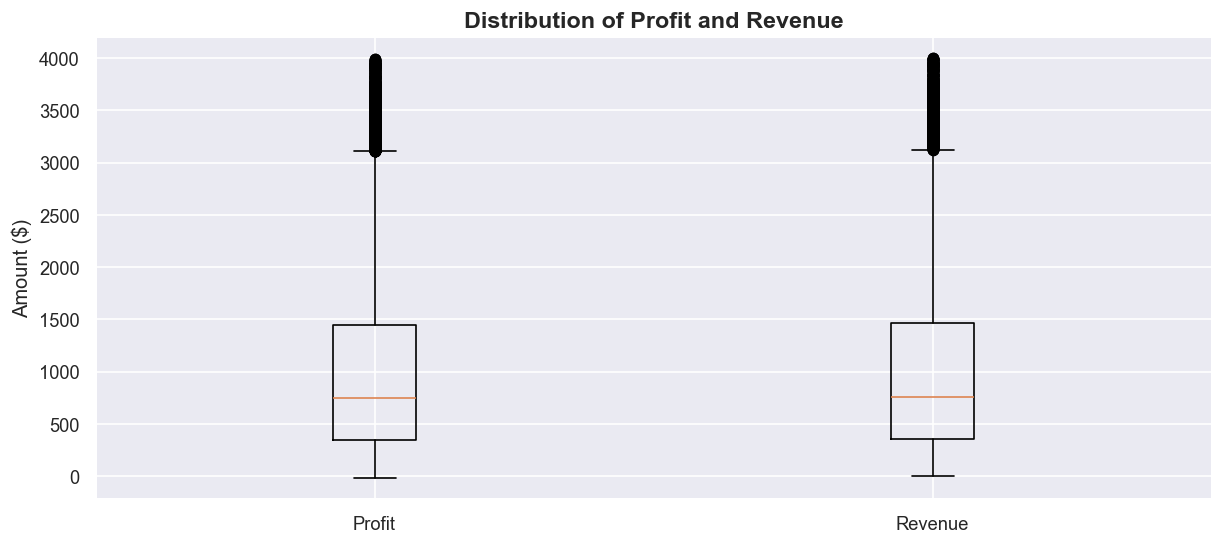

In [38]:
plt.boxplot([data['profit'], data['revenue']], labels=['Profit', 'Revenue'])

plt.ylabel("Amount ($)")
plt.title("Distribution of Profit and Revenue")

plt.show()

# Analyze Correlation Between Numerical Features
Study relationships between numerical variables.

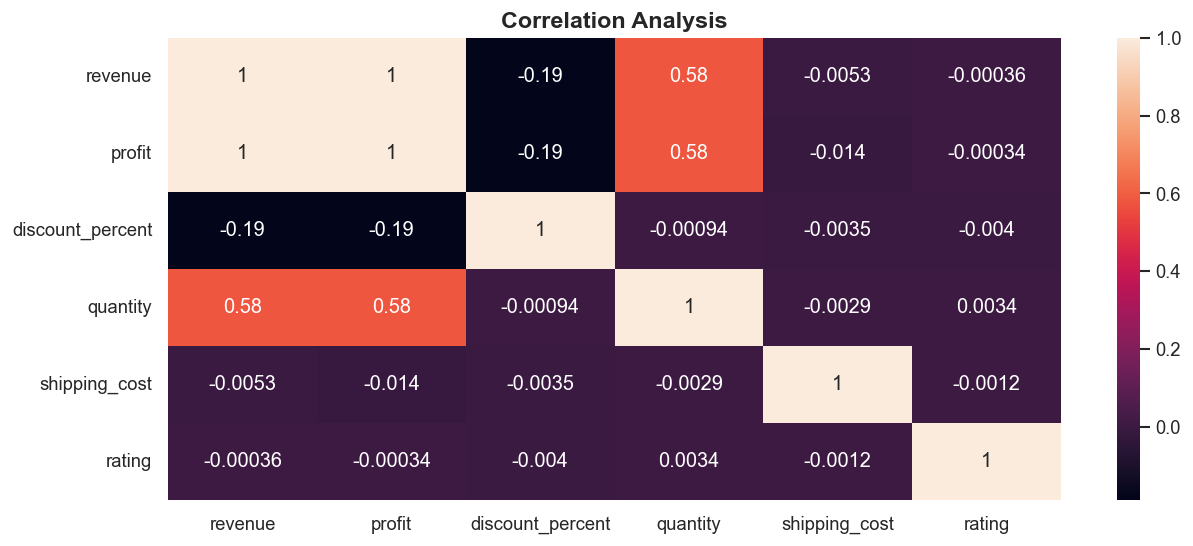

In [39]:
sns.heatmap(data[["revenue",
"profit",
"discount_percent",
"quantity",
"shipping_cost",
"rating"]].corr(),annot=True)
plt.title("Correlation Analysis")
plt.show()